# Generación de Data Sintética para Simulación de Inferencia

Genera **100,000 sesiones 100% sintéticas** (ninguna del dataset original) para simular un flujo real de inferencia.

- Se usa el mismo `CorrelatedAugmenter` del Notebook 4 para preservar distribuciones y correlaciones
- Distribución objetivo: **~1.5% vishing** (98,500 legítimas + 1,500 vishing)
- La data original 50K se usa solo como **referencia estadística** del augmentador, no se incluye en la salida
- Salida: `s3://poc-fraude-vishing/proyecto/data/inference_simulation/inference_100k.parquet`

In [1]:
%pip install --quiet "sagemaker<3"


[notice] A new release of pip is available: 23.0.1 -> 26.1.2
[notice] To update, run: python -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [1]:
import pandas as pd
import numpy as np
import boto3
import sagemaker
import time
import warnings
from datetime import datetime, timedelta
from scipy import stats as scipy_stats

warnings.filterwarnings('ignore')
np.random.seed(42)

sagemaker_session = sagemaker.Session()
role              = sagemaker.get_execution_role()
s3_client         = boto3.client('s3')

BUCKET      = 'poc-fraude-vishing'
BASE_PREFIX = 'proyecto'

S3_SOURCE_PATH = f's3://{BUCKET}/{BASE_PREFIX}/raw_data/biocatch_sinthetic_data.csv'
S3_OUTPUT_PATH = f's3://{BUCKET}/{BASE_PREFIX}/data/inference_simulation/inference_100k.parquet'

print(f'Fuente  : {S3_SOURCE_PATH}')
print(f'Destino : {S3_OUTPUT_PATH}')

sagemaker.config INFO - Not applying SDK defaults from location: /etc/xdg/sagemaker/config.yaml
sagemaker.config INFO - Not applying SDK defaults from location: /home/ec2-user/.config/sagemaker/config.yaml
Fuente  : s3://poc-fraude-vishing/proyecto/raw_data/biocatch_sinthetic_data.csv
Destino : s3://poc-fraude-vishing/proyecto/data/inference_simulation/inference_100k.parquet


## 1. Carga del dataset original (referencia estadística)

In [2]:
df_original = pd.read_csv(S3_SOURCE_PATH, parse_dates=['session_timestamp'])

print(f'Dataset original : {len(df_original):,} filas × {df_original.shape[1]} columnas')
print(f'  Legítimas: {(df_original["is_vishing"]==0).sum():,}')
print(f'  Vishing  : {(df_original["is_vishing"]==1).sum():,}  ({df_original["is_vishing"].mean()*100:.1f}%)')

Dataset original : 50,000 filas × 61 columnas
  Legítimas: 47,500
  Vishing  : 2,500  (5.0%)


## 2. Definición de columnas por tipo

In [3]:
continuous_cols = [
    'avg_keyhold_ms', 'avg_interkey_latency_ms', 'typing_speed_cps',
    'keystroke_variability', 'segmented_typing_ratio',
    'avg_touch_pressure', 'avg_touch_size_px', 'swipe_speed_px_s',
    'swipe_directional_variance', 'scroll_speed_avg',
    'device_tilt_angle_mean', 'device_tilt_variability',
    'gyro_rotation_rate_mean', 'accelerometer_jerk_mean',
    'avg_hesitation_duration_s', 'max_hesitation_duration_s',
    'total_dead_time_s', 'dead_time_ratio',
    'screen_transition_time_avg_s', 'data_familiarity_score',
    'session_duration_s', 'call_overlap_duration_s',
    'time_to_transaction_s',
    'errors_per_minute', 'interactions_per_s', 'hesitation_composite',
]

integer_cols = [
    'phone_motion_events', 'hesitation_count', 'dead_time_periods',
    'screens_visited', 'unique_screens_visited', 'unusual_screen_visits',
    'navigation_back_count', 'input_error_count', 'input_correction_count',
    'amount_field_corrections', 'beneficiary_field_corrections',
    'copy_paste_events', 'doodling_events', 'hour_of_day',
    'transaction_amount_cop',
]

binary_cols = [
    'is_atypical_hour', 'phone_call_active',
    'remote_access_tool_detected', 'suspicious_app_detected',
    'transaction_attempted', 'is_new_beneficiary',
]

# Features que usará el modelo (excluye BioCatch scores y otras descartadas)
MODEL_FEATURES = continuous_cols + integer_cols + binary_cols

print(f'Features continuas : {len(continuous_cols)}')
print(f'Features enteras   : {len(integer_cols)}')
print(f'Features binarias  : {len(binary_cols)}')
print(f'Total para modelo  : {len(MODEL_FEATURES)}')

Features continuas : 26
Features enteras   : 15
Features binarias  : 6
Total para modelo  : 47


## 3. CorrelatedAugmenter

In [4]:
class CorrelatedAugmenter:
    """
    Genera datos sintéticos preservando distribuciones marginales,
    estructura de correlación y restricciones de dominio.
    Idéntico al utilizado en el Notebook 4.
    """

    def __init__(self, df_class, continuous_cols, integer_cols, binary_cols):
        self.continuous_cols = continuous_cols
        self.integer_cols    = integer_cols
        self.binary_cols     = binary_cols
        self.all_cols        = continuous_cols + integer_cols + binary_cols

        self.df_class  = df_class[self.all_cols].copy()
        self.means     = self.df_class.mean()
        self.stds      = self.df_class.std()
        self.mins      = self.df_class.min()
        self.maxs      = self.df_class.max()

        self.binary_probs = {col: df_class[col].mean() for col in binary_cols}

        self.integer_distributions = {}
        for col in integer_cols:
            vals          = df_class[col].values
            unique, counts = np.unique(vals, return_counts=True)
            self.integer_distributions[col] = (unique, counts / counts.sum())

        cont_data          = df_class[continuous_cols].values
        self.corr_matrix   = np.corrcoef(cont_data.T) + np.eye(len(continuous_cols)) * 1e-6
        self.cholesky      = np.linalg.cholesky(self.corr_matrix)

        self.percentiles = {
            col: np.sort(cont_data[:, i])
            for i, col in enumerate(continuous_cols)
        }

    def generate(self, n_samples, noise_scale=0.03):
        result = pd.DataFrame(index=range(n_samples))

        z            = np.random.normal(0, 1, (n_samples, len(self.continuous_cols)))
        z_correlated = z @ self.cholesky.T
        u            = scipy_stats.norm.cdf(z_correlated)

        for i, col in enumerate(self.continuous_cols):
            sorted_vals = self.percentiles[col]
            n_orig      = len(sorted_vals)
            indices     = np.clip((u[:, i] * n_orig).astype(int), 0, n_orig - 1)
            values      = sorted_vals[indices]
            values      = values + np.random.normal(0, self.stds[col] * noise_scale, n_samples)
            result[col] = values

        for col in self.integer_cols:
            unique, probs = self.integer_distributions[col]
            sampled       = np.random.choice(unique, size=n_samples, p=probs)
            perturbation  = np.random.choice([-1, 0, 0, 0, 1], size=n_samples)
            mask          = np.random.random(n_samples) < noise_scale * 5
            result[col]   = sampled + perturbation * mask

        for col in self.binary_cols:
            result[col] = (np.random.random(n_samples) < self.binary_probs[col]).astype(int)

        self._enforce_constraints(result)
        return result

    def _enforce_constraints(self, df):
        for col in ['segmented_typing_ratio', 'avg_touch_pressure', 'dead_time_ratio',
                    'data_familiarity_score', 'keystroke_variability', 'swipe_directional_variance']:
            if col in df.columns:
                df[col] = df[col].clip(0, 1)

        for col in self.integer_cols:
            if col in df.columns:
                df[col] = df[col].round().clip(lower=0).astype(int)

        for col in self.binary_cols:
            if col in df.columns:
                df[col] = df[col].round().clip(0, 1).astype(int)

        if 'hour_of_day' in df.columns:
            df['hour_of_day'] = df['hour_of_day'].clip(0, 23)

        if 'device_tilt_angle_mean' in df.columns:
            df['device_tilt_angle_mean'] = df['device_tilt_angle_mean'].clip(0, 90)

        for col in self.continuous_cols:
            if col in df.columns and self.mins[col] >= 0:
                df[col] = df[col].clip(lower=0)

        if 'unique_screens_visited' in df.columns and 'screens_visited' in df.columns:
            df['unique_screens_visited'] = np.minimum(
                df['unique_screens_visited'], df['screens_visited'])

        if 'call_overlap_duration_s' in df.columns and 'phone_call_active' in df.columns:
            df.loc[df['phone_call_active'] == 0, 'call_overlap_duration_s'] = 0

        if 'time_to_transaction_s' in df.columns and 'transaction_attempted' in df.columns:
            df.loc[df['transaction_attempted'] == 0, 'time_to_transaction_s'] = 0

        if 'transaction_amount_cop' in df.columns and 'transaction_attempted' in df.columns:
            df.loc[df['transaction_attempted'] == 0, 'transaction_amount_cop'] = 0

        if 'is_new_beneficiary' in df.columns and 'transaction_attempted' in df.columns:
            df.loc[df['transaction_attempted'] == 0, 'is_new_beneficiary'] = 0


print('CorrelatedAugmenter definido.')

CorrelatedAugmenter definido.


## 4. Generación de 100K observaciones sintéticas

In [5]:
N_TOTAL        = 100_000
VISHING_PCT    = 0.015
N_VISHING      = int(N_TOTAL * VISHING_PCT)   # 1,500
N_LEGIT        = N_TOTAL - N_VISHING           # 98,500

print(f'Objetivo: {N_TOTAL:,} sesiones totalmente sintéticas')
print(f'  Legítimas : {N_LEGIT:,}  ({N_LEGIT/N_TOTAL*100:.1f}%)')
print(f'  Vishing   : {N_VISHING:,}   ({N_VISHING/N_TOTAL*100:.1f}%)')

df_orig_legit   = df_original[df_original['is_vishing'] == 0]
df_orig_vishing = df_original[df_original['is_vishing'] == 1]

print('\nEntrenando augmenters...')
t0 = time.time()
aug_legit   = CorrelatedAugmenter(df_orig_legit,   continuous_cols, integer_cols, binary_cols)
aug_vishing = CorrelatedAugmenter(df_orig_vishing, continuous_cols, integer_cols, binary_cols)
print(f'  Augmenters listos en {time.time()-t0:.1f}s')

print('\nGenerando sesiones legítimas...')
t0 = time.time()
df_synth_legit = aug_legit.generate(N_LEGIT, noise_scale=0.03)
df_synth_legit['is_vishing'] = 0
print(f'  {len(df_synth_legit):,} filas en {time.time()-t0:.1f}s')

print('\nGenerando sesiones vishing...')
t0 = time.time()
df_synth_vishing = aug_vishing.generate(N_VISHING, noise_scale=0.03)
df_synth_vishing['is_vishing'] = 1
print(f'  {len(df_synth_vishing):,} filas en {time.time()-t0:.1f}s')

Objetivo: 100,000 sesiones totalmente sintéticas
  Legítimas : 98,500  (98.5%)
  Vishing   : 1,500   (1.5%)

Entrenando augmenters...
  Augmenters listos en 0.1s

Generando sesiones legítimas...
  98,500 filas en 0.5s

Generando sesiones vishing...
  1,500 filas en 0.1s


In [6]:
# Ensamblar y mezclar
df_inference = pd.concat([df_synth_legit, df_synth_vishing], ignore_index=True)
df_inference = df_inference.sample(frac=1, random_state=42).reset_index(drop=True)

# Añadir session_id y timestamp para simular sesiones reales
df_inference.insert(0, 'session_id',
    [f'INF-{i:07d}' for i in range(1, len(df_inference) + 1)])

base_date  = datetime(2025, 6, 1)
timestamps = [
    base_date + timedelta(
        days=np.random.randint(0, 180),
        hours=int(df_inference.loc[i, 'hour_of_day']),
        minutes=np.random.randint(0, 60),
        seconds=np.random.randint(0, 60),
    )
    for i in range(len(df_inference))
]
df_inference.insert(1, 'session_timestamp', timestamps)

n  = len(df_inference)
nv = int(df_inference['is_vishing'].sum())
print(f'Dataset de inferencia ensamblado')
print(f'  Total      : {n:,}')
print(f'  Legítimas  : {n-nv:,}  ({(n-nv)/n*100:.2f}%)')
print(f'  Vishing    : {nv:,}   ({nv/n*100:.2f}%)')
print(f'  Columnas   : {df_inference.shape[1]}')

Dataset de inferencia ensamblado
  Total      : 100,000
  Legítimas  : 98,500  (98.50%)
  Vishing    : 1,500   (1.50%)
  Columnas   : 50


## 5. Validación rápida de distribuciones

Matplotlib is building the font cache; this may take a moment.


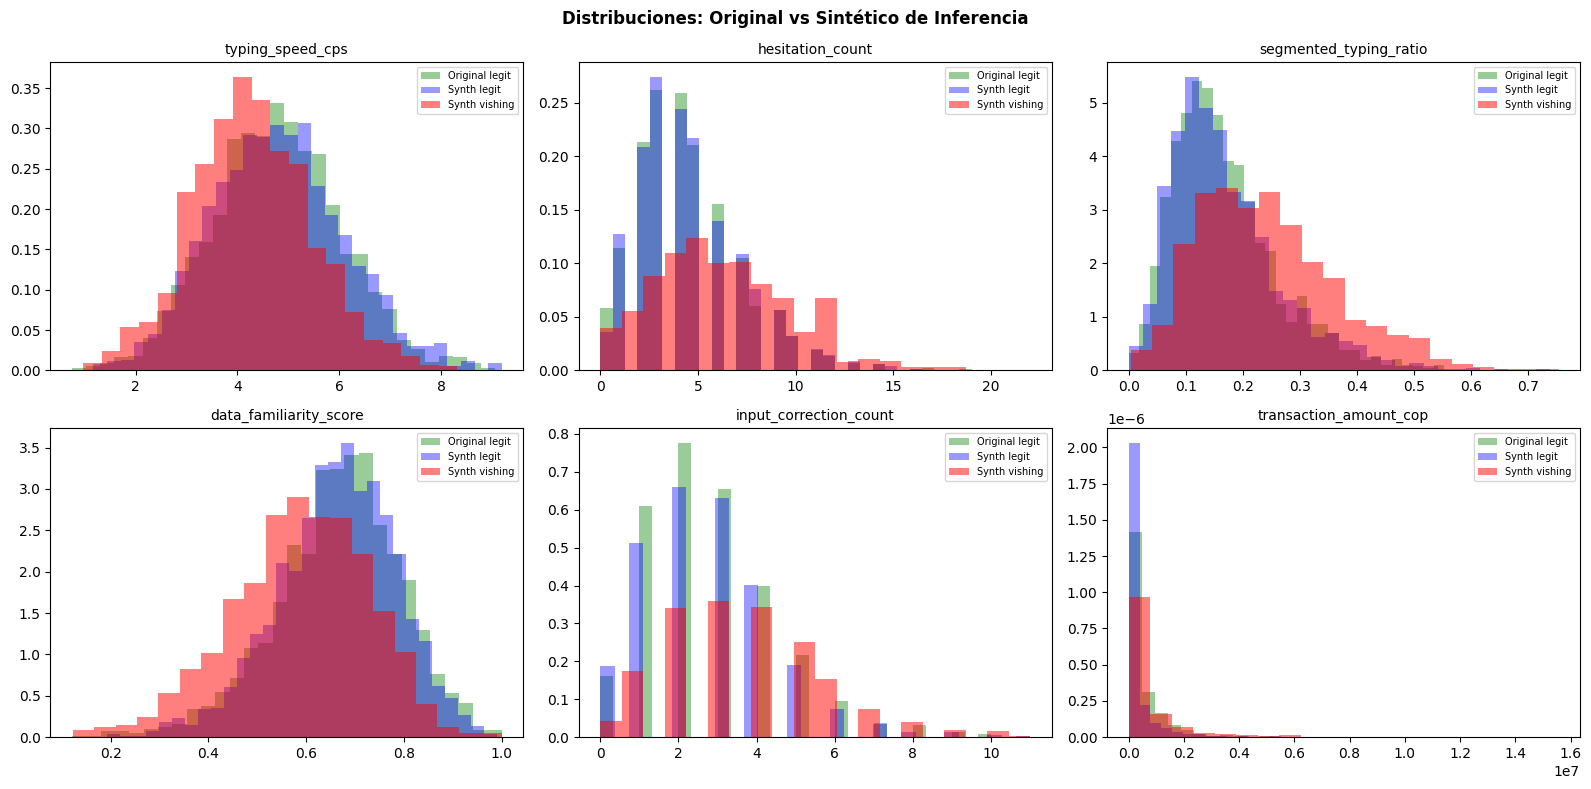

In [7]:
import matplotlib.pyplot as plt

key_feats = [
    'typing_speed_cps', 'hesitation_count', 'segmented_typing_ratio',
    'data_familiarity_score', 'input_correction_count', 'transaction_amount_cop',
]

fig, axes = plt.subplots(2, 3, figsize=(16, 8))

for ax, feat in zip(axes.flat, key_feats):
    orig_l = df_orig_legit[feat]
    orig_v = df_orig_vishing[feat]
    inf_l  = df_inference[df_inference['is_vishing'] == 0][feat]
    inf_v  = df_inference[df_inference['is_vishing'] == 1][feat]

    ax.hist(orig_l.sample(min(2000, len(orig_l))), bins=30, alpha=0.4,
            color='green', label='Original legit', density=True)
    ax.hist(inf_l.sample(min(2000, len(inf_l))),   bins=30, alpha=0.4,
            color='blue',  label='Synth legit',    density=True)
    ax.hist(inf_v.values,                           bins=20, alpha=0.5,
            color='red',   label='Synth vishing',  density=True)
    ax.set_title(feat, fontsize=10)
    ax.legend(fontsize=7)

plt.suptitle('Distribuciones: Original vs Sintético de Inferencia', fontweight='bold')
plt.tight_layout()
plt.show()

## 6. Guardar en S3

In [8]:
print(f'Guardando en {S3_OUTPUT_PATH}...')
t0 = time.time()

df_inference.to_parquet(S3_OUTPUT_PATH, engine='pyarrow', index=False)

print(f'Guardado en {time.time()-t0:.1f}s')
print(f'\nDataset de inferencia disponible en:')
print(f'  {S3_OUTPUT_PATH}')
print(f'\nUsar esta ruta en el simulador de inferencia (10_Realtime_Simulation.ipynb)')

Guardando en s3://poc-fraude-vishing/proyecto/data/inference_simulation/inference_100k.parquet...
Guardado en 2.4s

Dataset de inferencia disponible en:
  s3://poc-fraude-vishing/proyecto/data/inference_simulation/inference_100k.parquet

Usar esta ruta en el simulador de inferencia (10_Realtime_Simulation.ipynb)
